In [1]:
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except:
    !uv pip install pytorch-tabnet
    from pytorch_tabnet.tab_model import TabNetClassifier

try:
    import skrub
except:
    !uv pip install skrub
    import skrub

Using Python 3.12.13 environment at: /usr
Resolved 17 packages in 945ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
Prepared 1 package in 123ms
Installed 1 package in 7ms
 + pytorch-tabnet==4.1.0
Using Python 3.12.13 environment at: /usr
Resolved 27 packages in 1.11s
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt, seaborn as sns

from tqdm.notebook import tqdm
from time import time, sleep
import itertools

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

from sklearn.calibration import CalibrationDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, log_loss, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder
#, TargetEncoder

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Configuration --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## =================================================================================

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items(): #
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [7]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


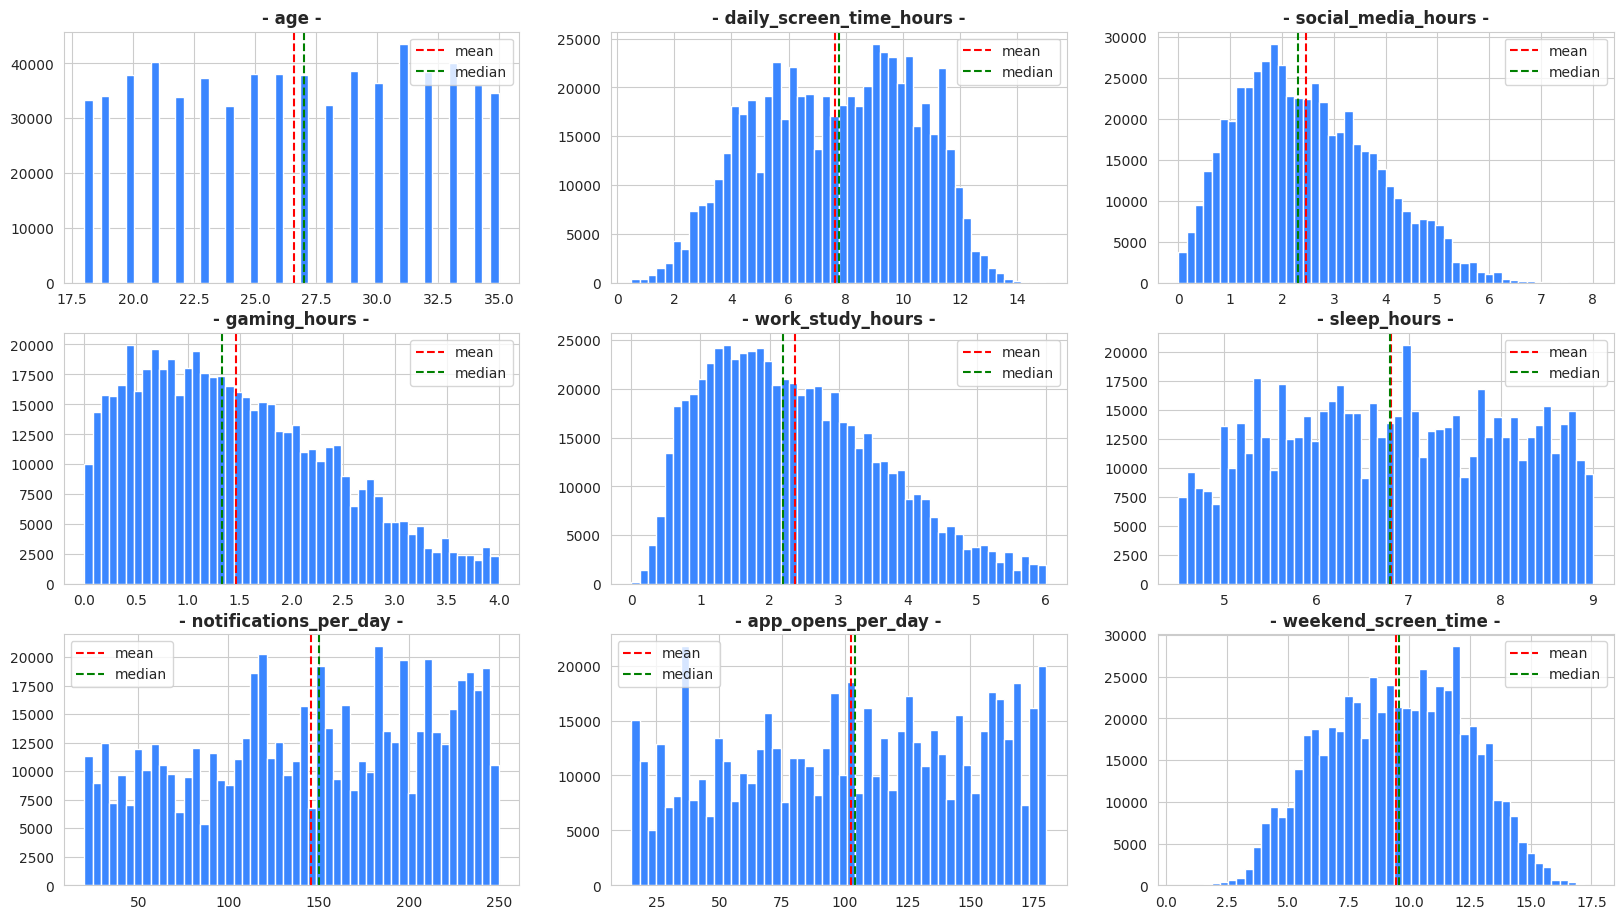

In [8]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'- {col} -', fontweight='semibold')
    plt.legend()
    
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Original,Test
age,18,18,18
daily_screen_time_hours,1389,900,1349
social_media_hours,721,551,703
gaming_hours,401,401,401
work_study_hours,600,551,601
sleep_hours,451,451,451
notifications_per_day,231,231,231
app_opens_per_day,166,166,166
weekend_screen_time,1437,1096,1404
gender,3,3,3


In [10]:
def get_class_weights(y):
    """
    y: Current y_labels -> array_like or series
    """
    wts_ = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return wts_

def get_sample_weights(y, y_true):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    """
    cls_ = np.unique(y_true)
    wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
    class_weights = dict(zip(cls_, wts_))
    return np.array([class_weights[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1.drop(columns=cols, inplace=True)
        X_va_1.drop(columns=cols, inplace=True)
        X_ts_1.drop(columns=cols, inplace=True)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [11]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         # orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [13]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}\n")

train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Features dropped: []



Series([], dtype: float64)

In [14]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# for df in [train, test, orig]:
#     df = add_frequency_condition(df, DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [15]:
# ## -- Arithmetic interaction --
# BANDS = ['u', 'g', 'r', 'i', 'z']
# COLOR_PAIRS = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
#     ('r', 'i'),
# ]

# for df in tqdm([train, test, orig], desc="Arithmetic features"):
#     for a, b in COLOR_PAIRS:
#         df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

#     for band in ['g', 'i']:
#         df[f"_div_{band}_redshift"] = (df[band] / (df['redshift']+1e-6)).astype('float32')

#     df['_log_redshift'] = np.log1p(df['redshift']).astype('float32')
#     df['_sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)
#     df['_stellar_locus_dist'] = np.sqrt((df['_g_r'] - 0.52)**2 + (df['_r_i'] - 0.25)**2)

#     # df["_mean_bands"] = df[BANDS].mean(axis=1)
#     # df["_std_bands"] = df[BANDS].std(axis=1)
#     # df["_skew_bands"] = df[BANDS].skew(axis=1)
#     # df["_max_bands"] = df[BANDS].max(axis=1)
#     # df["_min_bands"] = df[BANDS].min(axis=1)
#     # df["_range_bands"] = df["_max_bands"] - df["_min_bands"]

In [16]:
# ## -- Cyclic encoding --
# for df in tqdm([train, test, orig], desc="Cyclic features"):
#     for col in ['alpha', 'delta']:
#         for p in [180, 360]:
#             df[f"{col}_sin_{p}"] = np.sin(2 * np.pi * df[col] / p).astype('float32')
#             df[f"{col}_cos_{p}"] = np.cos(2 * np.pi * df[col] / p).astype('float32')

In [17]:
# ## -- Frequency encoding --
# FREQ_COLS = []

# print(f"\nCreating frequencies... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], test[col]]).value_counts(normalize=True) # orig[col], 
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test]: # , orig
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     FREQ_COLS.append(n)

# print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")
# train[FREQ_COLS]

In [18]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"_Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
# #     n_col = f"_Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
# #     n_col = f"_Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total interaction features: {len(INTER)}")

# train[INTER].head()

In [19]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    # num_to_cat = []
    # for col in num_features_:
    #     cat_name = f"{col}_cat"
    #     df[cat_name] = df[col].fillna('NaN').astype(str)
    #     num_to_cat.append(cat_name)

    # for c in num_features_:
    #     for i in [0,1]:
    #         df[f"{c}_round{i}"] = df[c].round(i)

    social = df['social_media_hours']
    gaming = df['gaming_hours']
    work = df['work_study_hours']
    daily = df['daily_screen_time_hours']
    sleep = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    # df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    # df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    # df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    # df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    # df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    # df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    # df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')
    
    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('int8')
        
    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    return df

train = apply_feature_engineering(train, NUMS, CATS)
test  = apply_feature_engineering(test, NUMS, CATS)
orig  = apply_feature_engineering(orig, NUMS, CATS)

train

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,missing_count
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,2
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,3
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,0
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1,5.27,0.313243,0.019525,0.114601,6.51,2.130195,0.654499,5.263153,14.516117,2


In [20]:
train.nunique(dropna=False)

id                         691369
age                            19
daily_screen_time_hours      1390
social_media_hours            722
gaming_hours                  402
work_study_hours              601
sleep_hours                   452
notifications_per_day         232
app_opens_per_day             167
weekend_screen_time          1438
gender                          4
stress_level                    4
academic_work_impact            3
addicted_label                  2
total_breakdown_hours        3063
social_ratio               219026
gaming_ratio               193189
work_ratio                 228336
unaccounted_screen_time      5374
screen_to_sleep_ratio      218479
weekend_vs_daily_ratio     196077
app_opens_per_hour         123193
notifications_per_hour     146328
missing_count                  12
dtype: int64

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [22]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [23]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE,
    target=TARGET,
    aggs=["mean", "count"], # mean, median, count, std, skew, nunique, max, min
    fill_nan=True,
)

TE_merging:   0%|          | 0/12 [00:00<?, ?it/s]

In [24]:
## -- Fill categorical --
train[CATS] = train[CATS].fillna('missing')
test[CATS]  = test[CATS].fillna('missing')
orig[CATS]  = orig[CATS].fillna('missing')

CATS_2 = ["missing_count"]
train[CATS_2] = train[CATS_2].fillna(-1)
test[CATS_2]  = test[CATS_2].fillna(-1)
# orig[NEW_CATS]  = orig[NEW_CATS].fillna(-1)

CATS.extend(CATS_2)
CATS

['gender', 'stress_level', 'academic_work_impact', 'missing_count']

In [25]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Features before:", len(FEATURES))

combined = pd.concat([train, test, orig])

## ------------------------------------------------------------
## -- Duplicate Nums as Cats --
TE_CATS = []
for c in NUMS:
    n = f"cat_{c}"
    combined[n] = combined[c].factorize()[0]
    # combined[n] = combined[n].astype('category')
    TE_CATS.append(n)
FEATURES.extend(TE_CATS)
print("Nums to Cats complete!")
## ------------------------------------------------------------

## -- Factorize all CATS data --
# for c in CATS:
#     combined[c] = combined[c].factorize()[0]
    # combined[c] = combined[c].astype('category')
# print("Label encoding complete!")
## ------------------------------------------------------------

print("Features after:", len(FEATURES))

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined

train

Features before: 46
Nums to Cats complete!
Features after: 55


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,missing_count,OTE_age_mean,OTE_age_count,OTE_daily_screen_time_hours_mean,OTE_daily_screen_time_hours_count,OTE_social_media_hours_mean,OTE_social_media_hours_count,OTE_gaming_hours_mean,OTE_gaming_hours_count,OTE_work_study_hours_mean,OTE_work_study_hours_count,OTE_sleep_hours_mean,OTE_sleep_hours_count,OTE_notifications_per_day_mean,OTE_notifications_per_day_count,OTE_app_opens_per_day_mean,OTE_app_opens_per_day_count,OTE_weekend_screen_time_mean,OTE_weekend_screen_time_count,OTE_gender_mean,OTE_gender_count,OTE_stress_level_mean,OTE_stress_level_count,OTE_academic_work_impact_mean,OTE_academic_work_impact_count,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.752660,376.0,0.707733,0.0,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553.0,0.707838,2437.0,0.707701,3753.0,0,-1,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,2.0,0.712500,400.0,0.333333,9.0,0.555556,18.0,0.707733,0.0,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,0.707733,0.0,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0,1,0,1,-1,1,1,1,1,-1,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,3.0,0.671679,399.0,0.294118,17.0,0.707733,0.0,0.707733,0.0,0.707733,0.0,0.833333,24.0,0.724138,29.0,0.659574,47.0,0.750000,4.0,0.702154,2461.0,0.711946,2503.0,0.707766,3747.0,2,1,-1,-1,-1,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,missing,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,1.0,0.702032,443.0,0.700000,10.0,0.615385,13.0,0.666667,15.0,0.894737,19.0,0.882353,17.0,0.729730,37.0,0.693878,49.0,0.500000,6.0,0.698311,2486.0,0.711946,2503.0,0.707733,0.0,3,2,2,1,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,2.0,0.748252,429.0,1.000000,6.0,0.545455,11.0,0.807692,26.0,0.666667,15.0,0.500000,18.0,0.707733,0.0,0.707733,0.0,1.000000,4.0,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0,4,3,3,2,3,4,-1,-1,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,missing,No,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,1.0,0.724747,396.0,1.000000,15.0,0.714286,21.0,0.600000,20.0,0.687500,16.0,0.588235,17.0,0.843750,32.0,0.693878,49.0,1.000000,9.0,0.722288,2553.0,0.707733,0.0,0.707701,3753.0,12,783,374,145,109,88,168,3,786,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,0.0,0.697727,440.0,0.357143,14.0,0.538462,13.0,0.300000,10.0,0.707733,0.0,0.863636,22.0,0.838710,31.0,0.733333,60.0,0.777778,9.0,0.702154,2461.0,0.703516,2560.0,0.707701,3753.0,7,342,163,82,248,312,102,77,154,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.707733,0.0,0.707733,0.0,0.707733,0.0,0.707733,0.0,0.562500,16.0,0.705882,17.0,0.707733,0.0,0.743590,39.0,0.428571,7.0,0.698311,2486.0,0.707838,2437.0,0.707701,3753.

In [26]:
# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train, INDI_COLS = appy_nan_indicator(train)
# test, _  = appy_nan_indicator(test)
# orig, _  = appy_nan_indicator(orig)

# print(INDI_COLS)
# train

In [27]:
# combined = pd.concat([train[FEATURES], test[FEATURES]])
# new_features = combined.columns.tolist()
# categorical_dims = { col: combined[col].nunique() for col in CATS+INDI_COLS }

# cat_in_features = [ f for f in CATS+INDI_COLS if f in new_features ]
# cat_idxs = [ new_features.index(f) for f in cat_in_features ]
# cat_dims = [ categorical_dims[f] for f in new_features if f in cat_in_features ]

# print(cat_idxs, cat_dims)

# del combined

# ML TRAINING

In [28]:
# -- REGULAR TRAINER --
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold, metrics=['log_loss'],
    use_orig=False, process_skrub=True, cat_cols=None, num_cols=None, show_df=False,
    ):

    print(f"\n===== Starting CV: {model_name} =====")
    t0 = time()

    X = train_df[features] 
    y = train_df[target]
    
    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))

    fold_scores  = []
    brier_scores = []
    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n ##### FOLD {idx}/{kfold.n_splits}", end=" | ")

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate orginal data --
        # if use_orig:
        #     X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        #     y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        #     # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        ## -- OPTION B: TE Merge original data --
        if use_orig:
            X_train, X_valid, X_test, orig_cols = orig_TE_data_propagate(
                orig,
                X_train,
                X_valid,
                X_test,
                features=BASE,
                target=TARGET,
                aggs=["mean", "count"],
                # "mean", "median", "count", "std", "skew", "nunique", "max", "min"
                fill_nan=True,
            )

        te_enc  = TargetEncoder(TE_CATS, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)

        for num_col in num_cols:
            scaler = StandardScaler()
            X_train[num_col] = scaler.fit_transform(X_train[[num_col]])
            X_valid[num_col] = scaler.transform(X_valid[[num_col]])
            X_test[num_col]  = scaler.transform(X_test[[num_col]])

        # EST = HistGradientBoostingRegressor(random_state=0)
        imputer = IterativeImputer(n_nearest_features=5, max_iter=10, tol=1e-3, random_state=0)
        X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
        X_valid[num_cols] = imputer.transform(X_valid[num_cols])
        X_test[num_cols]  = imputer.transform(X_test[num_cols])

        ## OPTION_1: =====================================================================
        if process_skrub:
            print("Skrub processing...", end=" | ")
            tabvec  = skrub.TableVectorizer(n_jobs=-1)
            X_train = tabvec.fit_transform(X_train, y_train)
            X_valid = tabvec.transform(X_valid)
            X_test  = tabvec.transform(X_test)

            if idx == 1:
                print(f"X_train shape: {X_train.shape}")

            model = TabNetClassifier(**params)
        else:
            ## -- Define cat features for cat embeddings --
            print("TabNet embedding processing...", end=" | ")
            combined = pd.concat([X_train, X_valid, X_test])

            for col in cat_cols:
                l_enc = LabelEncoder()
                l_enc.fit(combined[col].astype(str))

                X_train[col] = l_enc.transform(X_train[col].astype(str))
                X_valid[col] = l_enc.transform(X_valid[col].astype(str))
                X_test[col]  = l_enc.transform(X_test[col].astype(str))

            new_features = combined.columns.tolist()
            categorical_dims = { col: combined[col].nunique() for col in cat_cols }

            cat_in_features = [ f for f in cat_cols if f in new_features ]
            cat_idxs = [ new_features.index(f) for f in cat_in_features ]
            cat_dims = [ categorical_dims[f] for f in new_features if f in cat_in_features ]

            if idx == 1:
                print(f"X_train shape: {X_train.shape}")
                print()
                print("cat_idxs:", cat_idxs)
                print("cat_dims:", cat_dims)

            model = TabNetClassifier(**params, cat_idxs=cat_idxs, cat_dims=cat_dims)

        if show_df:
            display(X_train.head(3))

        model.fit(
            X_train.to_numpy(), y_train.to_numpy(),
            eval_set=[(X_valid.to_numpy(), y_valid.to_numpy())],
            max_epochs=200, # 200
            patience=10, # 10
            eval_metric=metrics,
            # weights=get_sample_weights(y_train, y_train),
            # batch_size=2048,
            # virtual_batch_size=512,
            drop_last=False,
        )

        ## -- Predict on validation and test sets --
        p0 = time()
        oof_preds[val_idx] = model.predict_proba(X_valid.to_numpy())[:, 1]
        print(f"oof prediction time:  {time() - p0:.2f} secs")
        p1 = time()
        test_preds += model.predict_proba(X_test.to_numpy())[:, 1] / kfold.n_splits
        print(f"test prediction time: {time() - p1:.2f} secs")

        ## -- Calculate and print fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"{CFG['YELLOW']}• Fold {idx} score: {fold_score:.6f} {CFG['RESET']}")

        ## -- Clean up memory -- 
        torch.cuda.empty_cache()

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"{CFG['FOLDS']}-FOLD CV: {model_name} | {X_train.shape}")
    print("==================================================")
    for i, score in enumerate(fold_scores, 1):
        print(f" • Fold {i} score: {score:.6f}")

    ## -- Final out-of-fold --
    oof_score = np.round(roc_auc_score(y, oof_preds), 6)
    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - t0) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_score,
        'model': model,
        'val_data': X_valid,
        'columns': X_valid.columns.tolist(),
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


In [29]:
# ## -- MULTI-SEED TRAINER --
# def Trainer_CV(
#     model_name, params, train_df, test_df, features, target, kfold, multi_seeds=[42, 0, 313],
#     metrics=['log_loss'], process_skrub=True, cat_cols=None, num_cols=None, show_df=False,
#     ):

#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     X = train_df[features] 
#     y = train_df[target].map(mapping)

#     num_cls = y.nunique()

#     # Calculate training class priors (the proportion of each class)
#     class_priors = y.value_counts(normalize=True).sort_index().values
#     print(f"Class priors (sorted by label index): {class_priors.round(4)}")
    
#     oof_preds  = np.zeros((len(X), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))

#     fold_scores  = []
#     brier_scores = []
#     feat_importances = []

#     n_splits = kfold.n_splits

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
#         print(f"\n ##### FOLD {idx}/{n_splits} | ", end='')

#         # Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()
        
#         oof_seeds  = np.zeros((len(X_valid), num_cls))
#         test_seeds = np.zeros((len(X_test), num_cls)) 

#         # ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
#         # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         # print(f" • Target Encoding {len(te_cols)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, ROUNDS, drop=True)

#         for col in num_cols:
#             scaler = StandardScaler()
#             X_train[col] = scaler.fit_transform(X_train[[col]])
#             X_test[col]  = scaler.transform(X_test[[col]])
#             X_valid[col] = scaler.transform(X_valid[[col]])

#             imputer = IterativeImputer(max_iter=50, tol=1e-5, random_state=0)
#             X_train[col] = imputer.fit_transform(X_train[[col]])
#             X_valid[col] = imputer.transform(X_valid[[col]])
#             X_test[col]  = imputer.transform(X_test[[col]])

#         ## OPTION_1: =====================================================================
#         if process_skrub:
#             print("Skrub processing... | ", end='')
#             tabvec  = skrub.TableVectorizer(n_jobs=-1)
#             X_train = tabvec.fit_transform(X_train, y_train)
#             X_valid = tabvec.transform(X_valid)
#             X_test  = tabvec.transform(X_test)

#             print(f"X_train shape: {X_train.shape} #####")

#             for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="-> Training seeds"):
#                 print(f"Training with seed -> {seed}")
#                 params["seed"] = seed
    
#                 ## -- Shuffle X_train --
#                 full_train = pd.concat([X_train, y_train], axis=1)
#                 X_train = full_train.sample(frac=1.0, random_state=seed).iloc[:, :-1].copy()
#                 y_train = full_train.sample(frac=1.0, random_state=seed).iloc[:, -1].copy()
    
#                 model = TabNetClassifier(**params)

#                 if show_df:
#                     display(X_train.head(3))
        
#                 model.fit(
#                     X_train.to_numpy(), y_train.to_numpy(),
#                     eval_set=[(X_valid.to_numpy(), y_valid.to_numpy())],
#                     max_epochs=100,
#                     patience=10,
#                     eval_metric=metrics,
#                     weights=get_sample_weights(y_train, y_train),
#                     # batch_size=2048,
#                     # virtual_batch_size=512,
#                     drop_last=False,
#                 )
    
#                 oof_seeds  += model.predict_proba(X_valid.to_numpy()) / len(multi_seeds)
#                 test_seeds += model.predict_proba(X_test.to_numpy()) / len(multi_seeds)
#                 print(f"\tSeed ({seed}) score: {balanced_acc(y_valid, model.predict_proba(X_valid.to_numpy())):.5f}")
#         else:
#             ## -- Define cat features for cat embeddings --
#             print("TabNet embedding processing... | ", end='')
#             combined = pd.concat([X_train, X_valid, X_test])

#             for col in cat_cols:
#                 l_enc = LabelEncoder()
#                 l_enc.fit(combined[col].astype(str))

#                 X_train[col] = l_enc.transform(X_train[col].astype(str))
#                 X_valid[col] = l_enc.transform(X_valid[col].astype(str))
#                 X_test[col]  = l_enc.transform(X_test[col].astype(str))

#             new_features = combined.columns.tolist()
#             categorical_dims = { col: combined[col].nunique() for col in cat_cols }

#             cat_in_features = [ f for f in cat_cols if f in new_features ]
#             cat_idxs = [ new_features.index(f) for f in cat_in_features ]
#             cat_dims = [ categorical_dims[f] for f in new_features if f in cat_in_features ]

#             print(f"X_train shape: {X_train.shape}")
#             print()
#             print('cat_idxs:', cat_idxs)
#             print('cat_dims:', cat_dims)

#             for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="-> Training seeds"):
#                 print(f"Training with seed -> {seed}")
#                 params["seed"] = seed

#                 ## -- Shuffle X_train --
#                 full_train = pd.concat([X_train, y_train], axis=1)
#                 X_train = full_train.sample(frac=1.0, random_state=seed).iloc[:, :-1].copy()
#                 y_train = full_train.sample(frac=1.0, random_state=seed).iloc[:, -1].copy()
    
#                 model = TabNetClassifier(**params, cat_idxs=cat_idxs, cat_dims=cat_dims)

#                 if show_df:
#                     display(X_train.head(3))
        
#                 model.fit(
#                     X_train.to_numpy(), y_train.to_numpy(),
#                     eval_set=[(X_valid.to_numpy(), y_valid.to_numpy())],
#                     max_epochs=100,
#                     patience=10,
#                     eval_metric=metrics,
#                     weights=get_sample_weights(y_train, y_train),
#                     # batch_size=2048,
#                     # virtual_batch_size=512,
#                     drop_last=False,
#                 )
    
#                 oof_seeds  += model.predict_proba(X_valid.to_numpy()) / len(multi_seeds)
#                 test_seeds += model.predict_proba(X_test.to_numpy()) / len(multi_seeds)
#                 print(f"\tSeed ({seed}) score: {balanced_acc(y_valid, model.predict_proba(X_valid.to_numpy())):.5f}") 

#         ## -- Predict on val and test sets --
#         # corrected_oof = oof_seeds / class_priors 
#         # corrected_oof = corrected_oof / corrected_oof.sum(axis=1, keepdims=True)
#         oof_preds[val_idx] = oof_seeds # corrected_oof

#         # corrected_test = test_seeds / class_priors 
#         # corrected_test = corrected_test / corrected_test.sum(axis=1, keepdims=True)
#         test_preds += test_seeds / n_splits # corrected_test / n_splits

#         ## -- Calculate and print fold score --
#         fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
#         brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

#         fold_scores.append(fold_score)
#         brier_scores.append(brier_score)

#         print('-'*50)
#         print(f"{CFG['YELLOW']} • Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} acc: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(balanced_acc(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'scores': oof_score,
#         'model': model,
#         'val_data': X_valid,
#         'columns': X_valid.columns.tolist(),
#     }

# print("⚙️ Training function ready ⚙️")

In [30]:
all_predictions = {}

USE_CALIBRATION = False
MULTI_SEEDS = [42, 777, 1234, 24611, 0]

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)

train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()
train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,missing_count,OTE_age_mean,OTE_age_count,OTE_daily_screen_time_hours_mean,OTE_daily_screen_time_hours_count,OTE_social_media_hours_mean,OTE_social_media_hours_count,OTE_gaming_hours_mean,OTE_gaming_hours_count,OTE_work_study_hours_mean,OTE_work_study_hours_count,OTE_sleep_hours_mean,OTE_sleep_hours_count,OTE_notifications_per_day_mean,OTE_notifications_per_day_count,OTE_app_opens_per_day_mean,OTE_app_opens_per_day_count,OTE_weekend_screen_time_mean,OTE_weekend_screen_time_count,OTE_gender_mean,OTE_gender_count,OTE_stress_level_mean,OTE_stress_level_count,OTE_academic_work_impact_mean,OTE_academic_work_impact_count,cat_age,cat_daily_screen_time_hours,cat_social_media_hours,cat_gaming_hours,cat_work_study_hours,cat_sleep_hours,cat_notifications_per_day,cat_app_opens_per_day,cat_weekend_screen_time,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.752660,376.0,0.707733,0.0,0.571429,14.0,0.700000,20.0,0.750000,20.0,0.869565,23.0,0.694444,36.0,0.851064,47.0,0.555556,9.0,0.722288,2553.0,0.707838,2437.0,0.707701,3753.0,0,-1,0,0,0,0,0,0,0,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,2.0,0.712500,400.0,0.333333,9.0,0.555556,18.0,0.707733,0.0,0.636364,11.0,0.583333,12.0,0.675000,40.0,0.588235,51.0,0.707733,0.0,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0,1,0,1,-1,1,1,1,1,-1,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,3.0,0.671679,399.0,0.294118,17.0,0.707733,0.0,0.707733,0.0,0.707733,0.0,0.833333,24.0,0.724138,29.0,0.659574,47.0,0.750000,4.0,0.702154,2461.0,0.711946,2503.0,0.707766,3747.0,2,1,-1,-1,-1,2,2,2,1,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,missing,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,1.0,0.702032,443.0,0.700000,10.0,0.615385,13.0,0.666667,15.0,0.894737,19.0,0.882353,17.0,0.729730,37.0,0.693878,49.0,0.500000,6.0,0.698311,2486.0,0.711946,2503.0,0.707733,0.0,3,2,2,1,2,3,3,3,2,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,2.0,0.748252,429.0,1.000000,6.0,0.545455,11.0,0.807692,26.0,0.666667,15.0,0.500000,18.0,0.707733,0.0,0.707733,0.0,1.000000,4.0,0.702154,2461.0,0.707838,2437.0,0.707701,3753.0,4,3,3,2,3,4,-1,-1,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,missing,No,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.719843,7.977729,1.0,0.724747,396.0,1.000000,15.0,0.714286,21.0,0.600000,20.0,0.687500,16.0,0.588235,17.0,0.843750,32.0,0.693878,49.0,1.000000,9.0,0.722288,2553.0,0.707733,0.0,0.707701,3753.0,12,783,374,145,109,88,168,3,786,1.0
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,3.05,0.539129,0.257970,0.086956,0.40,0.523520,2.455065,12.173878,64.057785,0.0,0.697727,440.0,0.357143,14.0,0.538462,13.0,0.300000,10.0,0.707733,0.0,0.863636,22.0,0.838710,31.0,0.733333,60.0,0.777778,9.0,0.702154,2461.0,0.703516,2560.0,0.707701,3753.0,7,342,163,82,248,312,102,77,154,1.0
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,2.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.707733,0.0,0.707733,0.0,0.707733,0.0,0.707733,0.0,0.562500,16.0,0.705882,17.0,0.707733,0.0,0.743590,39.0,0.428571,7.0,0.698311,2486.0,0.707838,2437.0,0.707701,3753.

In [31]:
# !rm -r /kaggle/working

In [32]:
# if all_predictions:
#     all_predictions.clear()

net_params = {
    # 'n_d': 2,
    # 'n_a': 2,
    # 'n_steps': 3,
    # 'gamma': 1.3,
    # 'n_independent': 2,
    # 'n_shared': 2,
    # 'epsilon': 1e-15,
    # 'lambda_sparse': 1e-3,
    # 'cat_emb_dim': 2,
    # 'mask_type': 'sparsemax',
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': {'lr': 0.01, 'weight_decay': 0.0},
    # 'scheduler_fn': torch.optim.lr_scheduler.StepLR,
    # 'scheduler_params': {'step_size': 20, 'gamma': 0.9},
    'seed': CFG['SEED'],
    'verbose': 1,
}

for VALUE in [6]:
    net_params['n_d'] = VALUE
    net_params['n_a'] = VALUE
    n = f"tabnet_nd{str(VALUE)}_fe{len(FEATURES)}"
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=net_params,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        metrics=['auc'],
        cat_cols=CATS,
        num_cols=[c for c in FEATURES if c not in CATS+TE_CATS],
        process_skrub=False,
        show_df=True,
        # use_orig=True,
        # multi_seeds=MULTI_SEEDS,
    )


===== Starting CV: tabnet_nd6_fe55 =====

 ##### FOLD 1/5 | TabNet embedding processing... | X_train shape: (553095, 55)

cat_idxs: [9, 10, 11, 21]
cat_dims: [4, 4, 3, 12]


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,missing_count,OTE_age_mean,OTE_age_count,OTE_daily_screen_time_hours_mean,OTE_daily_screen_time_hours_count,OTE_social_media_hours_mean,OTE_social_media_hours_count,OTE_gaming_hours_mean,OTE_gaming_hours_count,OTE_work_study_hours_mean,OTE_work_study_hours_count,OTE_sleep_hours_mean,OTE_sleep_hours_count,OTE_notifications_per_day_mean,OTE_notifications_per_day_count,OTE_app_opens_per_day_mean,OTE_app_opens_per_day_count,OTE_weekend_screen_time_mean,OTE_weekend_screen_time_count,OTE_gender_mean,OTE_gender_count,OTE_stress_level_mean,OTE_stress_level_count,OTE_academic_work_impact_mean,OTE_academic_work_impact_count,TE_cat_age_mean,TE_cat_daily_screen_time_hours_mean,TE_cat_social_media_hours_mean,TE_cat_gaming_hours_mean,TE_cat_work_study_hours_mean,TE_cat_sleep_hours_mean,TE_cat_notifications_per_day_mean,TE_cat_app_opens_per_day_mean,TE_cat_weekend_screen_time_mean
0,-0.508000,-0.261156,-0.488534,0.140090,-0.202911,0.531276,-0.361724,-1.343249,-0.297202,1,2,0,0.062812,-0.560845,0.192021,0.022451,-0.188972,-0.119003,0.058410,-0.649398,-0.014951,1,1.930238,-0.285476,-0.071707,-1.579091,-0.305207,0.551771,-0.06970,0.453785,0.320308,1.253110,1.524169,0.895230,-0.186917,0.325435,2.073334,0.268831,-0.627726,0.692566,1.412870,0.313452,0.045526,0.199308,-1.054961,0.264979,0.774182,0.711779,0.665823,0.661971,0.746836,0.751920,0.547685,0.945214,0.702710
1,-1.478552,-0.614305,-1.058350,-0.797368,0.528114,1.147011,-1.059623,-1.738275,-0.115687,0,2,0,-0.512625,-1.087106,-0.101482,1.379514,-0.119755,-0.923715,0.336433,-0.997051,-0.548977,4,0.212718,-0.008746,-1.445036,0.552699,-0.390328,1.168486,0.00704,-1.856062,-0.587231,-0.380446,-1.216388,-0.970932,-0.423291,0.661664,-1.767077,0.508787,-0.065206,-1.474570,-0.538383,0.130418,0.045526,0.199308,-1.054961,0.264979,0.717635,0.518261,0.296822,0.710193,0.735089,0.734478,0.661913,0.379834,0.711520
2,-1.672662,-0.937638,-0.389036,-1.185801,-0.873814,-0.449038,-0.179663,-0.885850,-0.703402,0,1,1,-2.178151,0.850998,-0.481375,-0.586569,1.388056,-0.735848,0.277501,-0.326739,0.179319,5,-1.533082,-0.020276,-1.588882,2.447624,0.425743,-1.606732,0.00704,-1.856062,-0.017248,-2.377015,1.177263,1.064882,0.174047,-0.262967,-0.724680,0.268831,0.091031,-0.511398,-0.538383,0.130418,1.283355,0.296417,1.012821,0.258445,0.660224,0.393036,0.709404,0.710977,0.710249,0.725231,0.599908,0.617205,0.314586


epoch 0  | loss: 0.28478 | val_0_auc: 0.95458 |  0:00:31s
epoch 1  | loss: 0.24471 | val_0_auc: 0.95738 |  0:01:03s
epoch 2  | loss: 0.23828 | val_0_auc: 0.95887 |  0:01:34s
epoch 3  | loss: 0.23288 | val_0_auc: 0.9607  |  0:02:05s
epoch 4  | loss: 0.22894 | val_0_auc: 0.96134 |  0:02:36s
epoch 5  | loss: 0.2272  | val_0_auc: 0.96209 |  0:03:06s
epoch 6  | loss: 0.22511 | val_0_auc: 0.96249 |  0:03:37s
epoch 7  | loss: 0.22431 | val_0_auc: 0.96285 |  0:04:07s
epoch 8  | loss: 0.22309 | val_0_auc: 0.96253 |  0:04:38s
epoch 9  | loss: 0.22352 | val_0_auc: 0.96305 |  0:05:09s
epoch 10 | loss: 0.22229 | val_0_auc: 0.96329 |  0:05:39s
epoch 11 | loss: 0.22127 | val_0_auc: 0.96377 |  0:06:10s
epoch 12 | loss: 0.22058 | val_0_auc: 0.96358 |  0:06:41s
epoch 13 | loss: 0.22019 | val_0_auc: 0.96363 |  0:07:12s
epoch 14 | loss: 0.21926 | val_0_auc: 0.96411 |  0:07:43s
epoch 15 | loss: 0.21913 | val_0_auc: 0.96439 |  0:08:14s
epoch 16 | loss: 0.21854 | val_0_auc: 0.9645  |  0:08:44s
epoch 17 | los

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,missing_count,OTE_age_mean,OTE_age_count,OTE_daily_screen_time_hours_mean,OTE_daily_screen_time_hours_count,OTE_social_media_hours_mean,OTE_social_media_hours_count,OTE_gaming_hours_mean,OTE_gaming_hours_count,OTE_work_study_hours_mean,OTE_work_study_hours_count,OTE_sleep_hours_mean,OTE_sleep_hours_count,OTE_notifications_per_day_mean,OTE_notifications_per_day_count,OTE_app_opens_per_day_mean,OTE_app_opens_per_day_count,OTE_weekend_screen_time_mean,OTE_weekend_screen_time_count,OTE_gender_mean,OTE_gender_count,OTE_stress_level_mean,OTE_stress_level_count,OTE_academic_work_impact_mean,OTE_academic_work_impact_count,TE_cat_age_mean,TE_cat_daily_screen_time_hours_mean,TE_cat_social_media_hours_mean,TE_cat_gaming_hours_mean,TE_cat_work_study_hours_mean,TE_cat_sleep_hours_mean,TE_cat_notifications_per_day_mean,TE_cat_app_opens_per_day_mean,TE_cat_weekend_screen_time_mean
0,-0.507093,-0.252678,-0.486764,0.141038,-0.204021,0.530889,-0.362466,-1.343680,-0.297086,1,2,0,0.063977,-0.387553,0.273555,0.020272,-0.183895,-0.118007,0.053365,-0.647898,-0.015097,1,1.932345,-0.287503,-0.070617,-1.578489,-0.306372,0.553241,-0.069038,0.455081,0.321991,1.253457,1.523624,0.896168,-0.187712,0.326824,2.072691,0.268613,-0.627443,0.695486,1.414829,0.313638,0.047568,0.198614,-1.053719,0.264592,0.773511,0.711005,0.655797,0.659380,0.730655,0.750598,0.544752,0.950643,0.704147
1,-1.477121,-0.613580,-1.056662,-0.520325,0.526697,1.146491,-1.060273,-1.738681,-0.112534,0,2,0,-0.511208,-1.085171,-0.023508,1.376413,-0.119850,-0.923336,0.336315,-1.000876,-0.549745,4,0.213472,-0.010026,-1.442768,0.551428,-0.391578,1.170137,0.007632,-1.854798,-0.586418,-0.379485,-1.216055,-0.975887,-0.424190,0.662809,-1.768103,0.508404,-0.064947,-1.472131,-0.537169,0.130746,0.047568,0.198614,-1.053719,0.264592,0.718211,0.538469,0.266688,0.710743,0.718949,0.724128,0.668489,0.394348,0.709783
2,-1.671126,-0.936936,-0.487040,-0.690455,-0.945399,-0.449215,-0.180429,-0.886310,-0.702983,0,1,1,-2.176004,0.590931,-0.228467,-0.642516,1.386605,-0.735355,0.276138,-0.328492,0.178726,5,-1.533702,-0.021588,-1.586491,2.444688,0.425308,-1.605895,0.007632,-1.854798,-0.015888,-2.375304,1.176829,1.066355,0.173413,-0.261150,-0.725602,0.268613,0.091284,-0.508745,-0.537169,0.130746,1.284941,0.295843,1.013820,0.258050,0.658723,0.368609,0.709142,0.711271,0.712189,0.724304,0.624242,0.618958,0.310101


epoch 0  | loss: 0.29205 | val_0_auc: 0.95404 |  0:00:30s
epoch 1  | loss: 0.24838 | val_0_auc: 0.95637 |  0:01:00s
epoch 2  | loss: 0.24406 | val_0_auc: 0.95768 |  0:01:30s
epoch 3  | loss: 0.23638 | val_0_auc: 0.96149 |  0:02:01s
epoch 4  | loss: 0.23018 | val_0_auc: 0.96254 |  0:02:31s
epoch 5  | loss: 0.22905 | val_0_auc: 0.96278 |  0:03:01s
epoch 6  | loss: 0.22669 | val_0_auc: 0.96315 |  0:03:32s
epoch 7  | loss: 0.22504 | val_0_auc: 0.96368 |  0:04:02s
epoch 8  | loss: 0.22474 | val_0_auc: 0.9638  |  0:04:31s
epoch 9  | loss: 0.22324 | val_0_auc: 0.96418 |  0:05:02s
epoch 10 | loss: 0.22273 | val_0_auc: 0.96448 |  0:05:32s
epoch 11 | loss: 0.22268 | val_0_auc: 0.96436 |  0:06:02s
epoch 12 | loss: 0.22202 | val_0_auc: 0.9647  |  0:06:31s
epoch 13 | loss: 0.22101 | val_0_auc: 0.96496 |  0:07:01s
epoch 14 | loss: 0.2207  | val_0_auc: 0.96499 |  0:07:31s
epoch 15 | loss: 0.22058 | val_0_auc: 0.96507 |  0:08:02s
epoch 16 | loss: 0.21989 | val_0_auc: 0.96515 |  0:08:31s
epoch 17 | los

...

epoch 0  | loss: 0.29241 | val_0_auc: 0.95539 |  0:00:34s
epoch 1  | loss: 0.24688 | val_0_auc: 0.95812 |  0:01:06s
epoch 2  | loss: 0.24004 | val_0_auc: 0.9603  |  0:01:42s
epoch 3  | loss: 0.23337 | val_0_auc: 0.96228 |  0:02:15s
epoch 4  | loss: 0.22988 | val_0_auc: 0.96267 |  0:02:49s
epoch 5  | loss: 0.22847 | val_0_auc: 0.96141 |  0:03:24s
epoch 6  | loss: 0.22719 | val_0_auc: 0.96348 |  0:03:59s
epoch 7  | loss: 0.2258  | val_0_auc: 0.96341 |  0:04:30s
epoch 8  | loss: 0.2254  | val_0_auc: 0.9638  |  0:05:02s
epoch 9  | loss: 0.22388 | val_0_auc: 0.96439 |  0:05:41s
epoch 10 | loss: 0.22282 | val_0_auc: 0.96443 |  0:06:15s
epoch 11 | loss: 0.22216 | val_0_auc: 0.96438 |  0:06:47s
epoch 12 | loss: 0.22188 | val_0_auc: 0.96457 |  0:07:20s
epoch 13 | loss: 0.22169 | val_0_auc: 0.96487 |  0:07:52s
epoch 14 | loss: 0.22063 | val_0_auc: 0.96495 |  0:08:24s
epoch 15 | loss: 0.22001 | val_0_auc: 0.96492 |  0:08:56s
epoch 16 | loss: 0.22015 | val_0_auc: 0.96537 |  0:09:27s
epoch 17 | los

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,missing_count,OTE_age_mean,OTE_age_count,OTE_daily_screen_time_hours_mean,OTE_daily_screen_time_hours_count,OTE_social_media_hours_mean,OTE_social_media_hours_count,OTE_gaming_hours_mean,OTE_gaming_hours_count,OTE_work_study_hours_mean,OTE_work_study_hours_count,OTE_sleep_hours_mean,OTE_sleep_hours_count,OTE_notifications_per_day_mean,OTE_notifications_per_day_count,OTE_app_opens_per_day_mean,OTE_app_opens_per_day_count,OTE_weekend_screen_time_mean,OTE_weekend_screen_time_count,OTE_gender_mean,OTE_gender_count,OTE_stress_level_mean,OTE_stress_level_count,OTE_academic_work_impact_mean,OTE_academic_work_impact_count,TE_cat_age_mean,TE_cat_daily_screen_time_hours_mean,TE_cat_social_media_hours_mean,TE_cat_gaming_hours_mean,TE_cat_work_study_hours_mean,TE_cat_sleep_hours_mean,TE_cat_notifications_per_day_mean,TE_cat_app_opens_per_day_mean,TE_cat_weekend_screen_time_mean
3,-1.090507,-0.449086,-0.920208,-0.043011,0.789266,1.656455,-0.513739,-0.180045,-0.287855,2,1,2,0.268844,-0.972305,0.216627,1.492653,-0.809035,-0.925925,0.037207,-0.105138,-0.296555,1,-0.235507,0.486843,-0.100076,0.788523,-0.069460,0.397880,-0.400161,-0.124738,1.476276,1.072206,1.644609,-0.122688,0.242230,0.410591,-0.223892,0.388984,-0.834002,-0.027968,-0.909885,0.180243,1.284375,0.296738,-0.022388,-3.829859,0.699152,0.366272,0.445376,0.620891,0.880187,0.803670,0.616624,0.686406,0.744045
4,-0.119732,1.307865,-0.456556,1.442445,-0.331564,-1.258831,0.718926,0.498668,1.368107,0,2,0,0.507844,-1.190290,0.483941,-1.053288,1.146706,2.076781,-0.270505,0.114684,-0.425866,4,1.743263,0.325183,1.000490,-0.158451,-0.444479,0.089543,0.998377,1.146833,-0.344242,0.345442,-2.015284,0.046920,-0.025041,-2.699744,-0.021367,-2.551054,1.015148,-0.509419,-0.537272,0.130501,0.046463,0.199731,-1.055327,0.264449,0.777036,0.998632,0.645204,0.927524,0.654754,0.626575,0.709778,0.710375,0.998738
6,-1.672972,-1.250373,-0.654178,-0.342240,-1.158275,-1.388400,1.124095,-0.720896,-0.707973,2,1,1,-0.695257,0.392685,0.645671,-0.757949,-0.715682,-0.696481,0.860839,0.003755,1.547928,0,-1.534949,-0.021231,-1.200642,0.788523,-0.688241,1.168721,-0.951100,0.222054,1.377425,0.708824,-0.974846,0.894957,-1.147143,0.578717,-1.535163,0.328984,1.015148,-0.750144,-0.909885,0.180243,1.284375,0.296738,1.012205,0.257904,0.659323,0.227500,0.563218,0.635395,0.687111,0.714709,0.448533,0.407475,0.387133


epoch 0  | loss: 0.29508 | val_0_auc: 0.95617 |  0:00:30s
epoch 1  | loss: 0.24678 | val_0_auc: 0.95827 |  0:01:01s
epoch 2  | loss: 0.24198 | val_0_auc: 0.95995 |  0:01:32s
epoch 3  | loss: 0.23686 | val_0_auc: 0.96133 |  0:02:02s
epoch 4  | loss: 0.23281 | val_0_auc: 0.96271 |  0:02:33s
epoch 5  | loss: 0.23002 | val_0_auc: 0.96335 |  0:03:04s
epoch 6  | loss: 0.22759 | val_0_auc: 0.96388 |  0:03:34s
epoch 7  | loss: 0.22578 | val_0_auc: 0.96457 |  0:04:06s
epoch 8  | loss: 0.2265  | val_0_auc: 0.96427 |  0:04:36s
epoch 9  | loss: 0.22447 | val_0_auc: 0.96396 |  0:05:07s
epoch 10 | loss: 0.22236 | val_0_auc: 0.96521 |  0:05:38s
epoch 11 | loss: 0.22183 | val_0_auc: 0.96517 |  0:06:09s
epoch 12 | loss: 0.2227  | val_0_auc: 0.96433 |  0:06:40s
epoch 13 | loss: 0.22272 | val_0_auc: 0.96494 |  0:07:11s
epoch 14 | loss: 0.22234 | val_0_auc: 0.96493 |  0:07:41s
epoch 15 | loss: 0.22116 | val_0_auc: 0.96531 |  0:08:12s
epoch 16 | loss: 0.22064 | val_0_auc: 0.96518 |  0:08:43s
epoch 17 | los

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,missing_count,OTE_age_mean,OTE_age_count,OTE_daily_screen_time_hours_mean,OTE_daily_screen_time_hours_count,OTE_social_media_hours_mean,OTE_social_media_hours_count,OTE_gaming_hours_mean,OTE_gaming_hours_count,OTE_work_study_hours_mean,OTE_work_study_hours_count,OTE_sleep_hours_mean,OTE_sleep_hours_count,OTE_notifications_per_day_mean,OTE_notifications_per_day_count,OTE_app_opens_per_day_mean,OTE_app_opens_per_day_count,OTE_weekend_screen_time_mean,OTE_weekend_screen_time_count,OTE_gender_mean,OTE_gender_count,OTE_stress_level_mean,OTE_stress_level_count,OTE_academic_work_impact_mean,OTE_academic_work_impact_count,TE_cat_age_mean,TE_cat_daily_screen_time_hours_mean,TE_cat_social_media_hours_mean,TE_cat_gaming_hours_mean,TE_cat_work_study_hours_mean,TE_cat_sleep_hours_mean,TE_cat_notifications_per_day_mean,TE_cat_app_opens_per_day_mean,TE_cat_weekend_screen_time_mean
0,-0.506769,-0.251701,-0.486470,0.138912,-0.205072,0.531828,-0.363672,-1.343812,-0.297817,1,2,0,0.062891,-0.394780,0.190308,0.019595,-0.185621,-0.119018,0.053756,-0.646000,-0.015537,1,1.932737,-0.286220,-0.070459,-1.578235,-0.306786,0.553388,-0.067413,0.454546,0.321421,1.253597,1.522946,0.896074,-0.186907,0.326567,2.072704,0.269028,-0.627646,0.694433,1.416771,0.313735,0.046369,0.198560,-1.055056,0.264920,0.770579,0.710983,0.651693,0.653442,0.734648,0.757246,0.546263,0.952199,0.729708
1,-1.476904,-0.613706,-1.056094,-0.524628,0.525369,1.147450,-1.061617,-1.738661,-0.114596,0,2,0,-0.512019,-1.084175,0.149742,1.376629,-0.119047,-0.923800,0.337654,-0.996422,-0.550257,4,0.214058,-0.009342,-1.442637,0.552139,-0.391974,1.169399,0.009260,-1.854954,-0.586655,-0.381143,-1.216339,-0.973826,-0.423415,0.662718,-1.766245,0.508882,-0.065126,-1.472061,-0.536077,0.130831,0.046369,0.198560,-1.055056,0.264920,0.717025,0.546335,0.272076,0.710745,0.742157,0.740361,0.661837,0.390683,0.710254
2,-1.670931,-0.937001,-0.503246,-0.700934,-0.922528,-0.448306,-0.181599,-0.886618,-0.704012,0,1,1,-2.176019,0.836663,-0.026769,-0.616852,1.390490,-0.735898,0.275400,-0.327775,0.177918,5,-1.532919,-0.020879,-1.586363,2.445806,0.424741,-1.602651,0.009260,-1.854954,-0.016335,-2.379158,1.176201,1.066065,0.174262,-0.261697,-0.724245,0.269028,0.091111,-0.509175,-0.536077,0.130831,1.284122,0.295828,1.012700,0.258385,0.657503,0.397779,0.707902,0.710917,0.709697,0.723386,0.630861,0.618984,0.314565


epoch 0  | loss: 0.28364 | val_0_auc: 0.9557  |  0:00:30s
epoch 1  | loss: 0.24353 | val_0_auc: 0.95735 |  0:01:01s
epoch 2  | loss: 0.23909 | val_0_auc: 0.95874 |  0:01:33s
epoch 3  | loss: 0.2343  | val_0_auc: 0.96084 |  0:02:04s
epoch 4  | loss: 0.22924 | val_0_auc: 0.96214 |  0:02:39s
epoch 5  | loss: 0.22596 | val_0_auc: 0.96243 |  0:03:10s
epoch 6  | loss: 0.22506 | val_0_auc: 0.9625  |  0:03:41s
epoch 7  | loss: 0.22361 | val_0_auc: 0.96327 |  0:04:12s
epoch 8  | loss: 0.22216 | val_0_auc: 0.96375 |  0:04:43s
epoch 9  | loss: 0.22252 | val_0_auc: 0.9639  |  0:05:14s
epoch 10 | loss: 0.2214  | val_0_auc: 0.96353 |  0:05:45s
epoch 11 | loss: 0.22068 | val_0_auc: 0.96399 |  0:06:15s
epoch 12 | loss: 0.22218 | val_0_auc: 0.96397 |  0:06:46s
epoch 13 | loss: 0.2206  | val_0_auc: 0.96395 |  0:07:18s
epoch 14 | loss: 0.22051 | val_0_auc: 0.96441 |  0:07:51s
epoch 15 | loss: 0.21951 | val_0_auc: 0.96449 |  0:08:21s
epoch 16 | loss: 0.21959 | val_0_auc: 0.96448 |  0:08:51s
epoch 17 | los

In [33]:
# TE(TE_CATS) + ORIG(mean, count) + apply_feature_engineering()
# ==================================================
# 5-FOLD CV: tabnet_nd6 | (165928, 55)
# ==================================================
#  • Fold 1 score: 0.963283
#  • Fold 2 score: 0.963813
#  • Fold 3 score: 0.963056
#  • Fold 4 score: 0.963842
#  • Fold 5 score: 0.963258
# -------------------------------------------------|
# OOF score: 0.963313
# AVG score: 0.963450 ± 0.000318
# -------------------------------------------------|
# 38.97 mins

# ==================================================
# 5-FOLD CV: tabnet_nd6 | (165928, 55) GPU
# ==================================================
#  • Fold 1 score: 0.962706
#  • Fold 2 score: 0.964220
#  • Fold 3 score: 0.962207
#  • Fold 4 score: 0.964841
#  • Fold 5 score: 0.963831
# -------------------------------------------------|
# OOF score: 0.9635
# AVG score: 0.963561 ± 0.000970
# -------------------------------------------------|
# 31.07 mins

# ==================================================
# 5-FOLD CV: tabnet_nd6 | (165928, 55) CPU
# ==================================================
#  • Fold 1 score: 0.963516
#  • Fold 2 score: 0.963964
#  • Fold 3 score: 0.962673
#  • Fold 4 score: 0.963833
#  • Fold 5 score: 0.963948
# -------------------------------------------------|
# OOF score: 0.963482
# AVG score: 0.963587 ± 0.000484
# -------------------------------------------------|
# 76.28 mins

In [34]:
# vec_params = {
#     'n_d': 2, # 6
#     'n_a': 2, # 6
#     # 'n_steps': 3,
#     # 'gamma': 1.3,
#     # 'n_independent': 2,
#     # 'n_shared': 2,
#     # 'epsilon': 1e-15,
#     # 'lambda_sparse': 1e-3,
#     # 'cat_emb_dim': 2,
#     # 'mask_type': 'sparsemax',
#     'optimizer_fn': torch.optim.Adam,
#     'optimizer_params': {'lr': 0.01, 'weight_decay': 0.0},
#     # 'scheduler_fn': torch.optim.lr_scheduler.StepLR,
#     # 'scheduler_params': {'step_size': 20, 'gamma': 0.9},
#     'verbose': 1,
#     'seed': CFG['SEED'],
# }

# # n = 'tabvec' vec_ND6_indicator_multi_seeds_5
# ## ----------------------------------------------
# for VALUE in [2]: # , 6, 8
#     vec_params['n_d'] = VALUE
#     vec_params['n_a'] = VALUE
#     n = f"tabvec_nd{str(VALUE)}"
#     all_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=vec_params,
#         train_df=train_data,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kfold=skf,
#         metrics=['auc'],
#         process_skrub=True,
#         cat_cols=CATS,
#         num_cols=NUMS,
#         show_df=True,
#         # multi_seeds=MULTI_SEEDS,
#         # use_orig=True,
#     )

In [35]:
# ==================================================
# 5-FOLD CV: tabvec_nd2 | (165928, 29)
# ==================================================
#  • Fold 1 score: 0.960451
#  • Fold 2 score: 0.878918
#  • Fold 3 score: 0.908449
#  • Fold 4 score: 0.894779
#  • Fold 5 score: 0.904235
# -------------------------------------------------|
# OOF score: 0.894696
# AVG score: 0.909366 ± 0.027483
# -------------------------------------------------|
# 18.99 mins

In [36]:
# !rm -r /kaggle/working

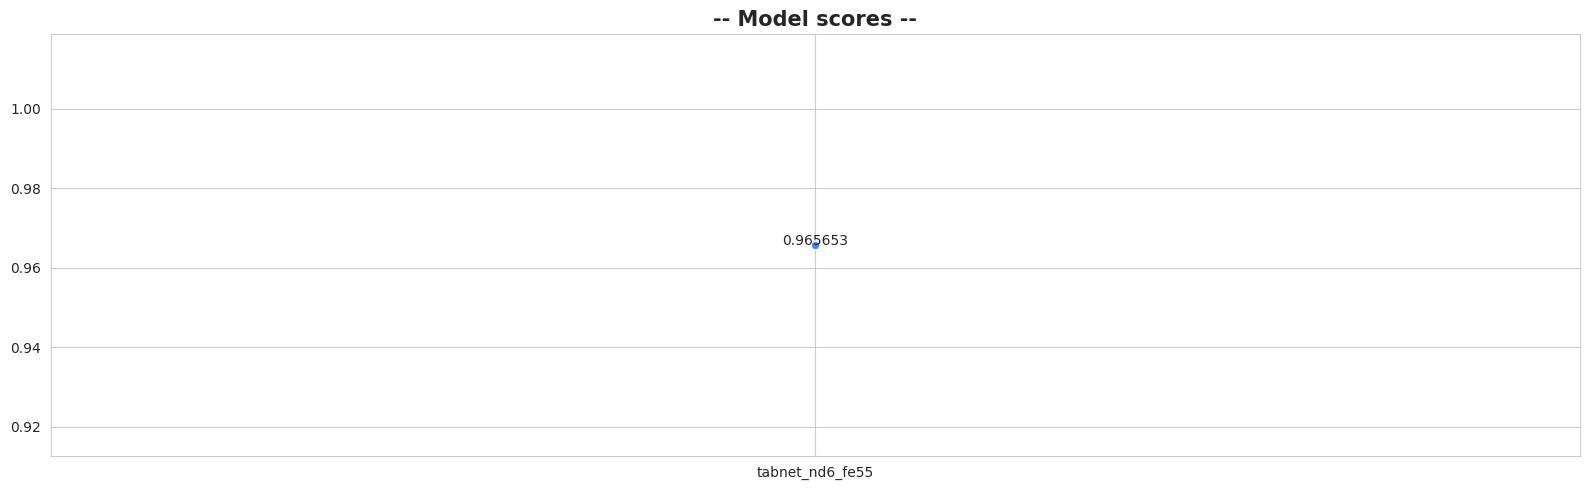

In [37]:
## -- Get model scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_scores)), all_scores.values(), alpha=0.3)
ax.set_title("-- Model scores --", fontsize=15, fontweight="semibold")
ax.tick_params("x", rotation=0)

add_ = 1e-6
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

# ax.set_ylim(0.94, 0.97)
plt.tight_layout()
plt.show()

tabnet_nd6_fe55_965653 saved!


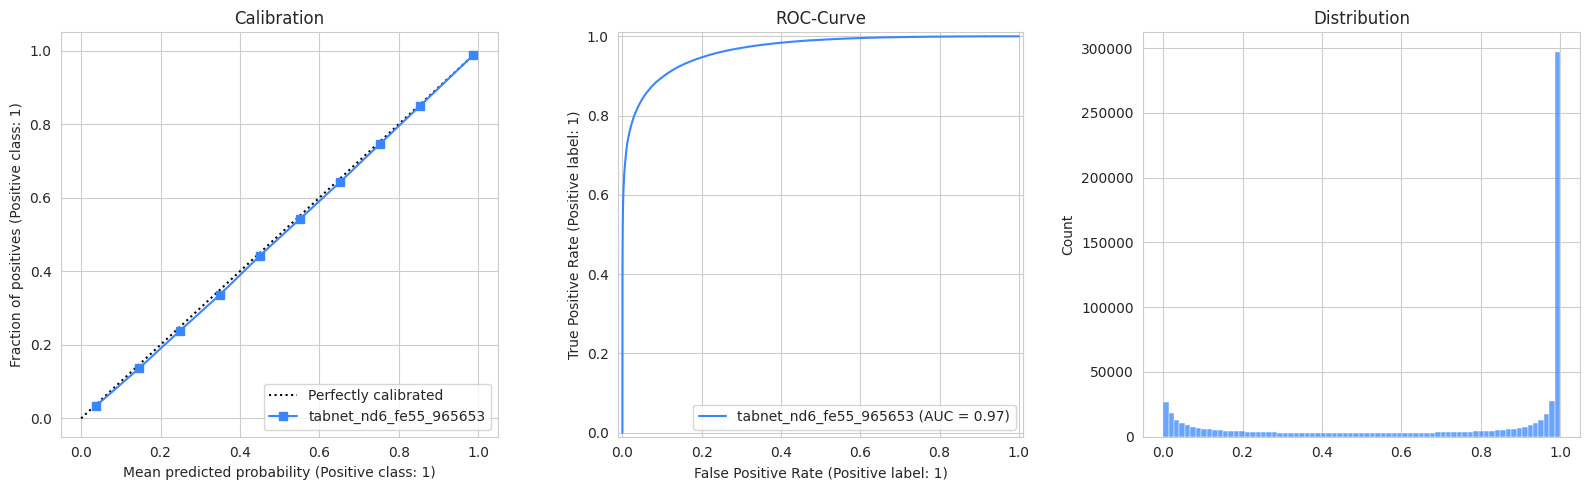

In [38]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"ROC-Curve")

            sns.histplot(data_, ax=axs[2])
            axs[2].set_title(f"Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [39]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{n} saved! {y.shape}")

            model_results[n] = y

tabnet_nd6_fe55_965653 saved! (296302,)


In [40]:
pd.DataFrame(model_results)

,tabnet_nd6_fe55_965653
0,0.997911
1,0.968151
2,0.785980
3,0.996512
4,0.997522
...,...
296297,0.999993
296298,0.812950
296299,0.197581
296300,0.754024


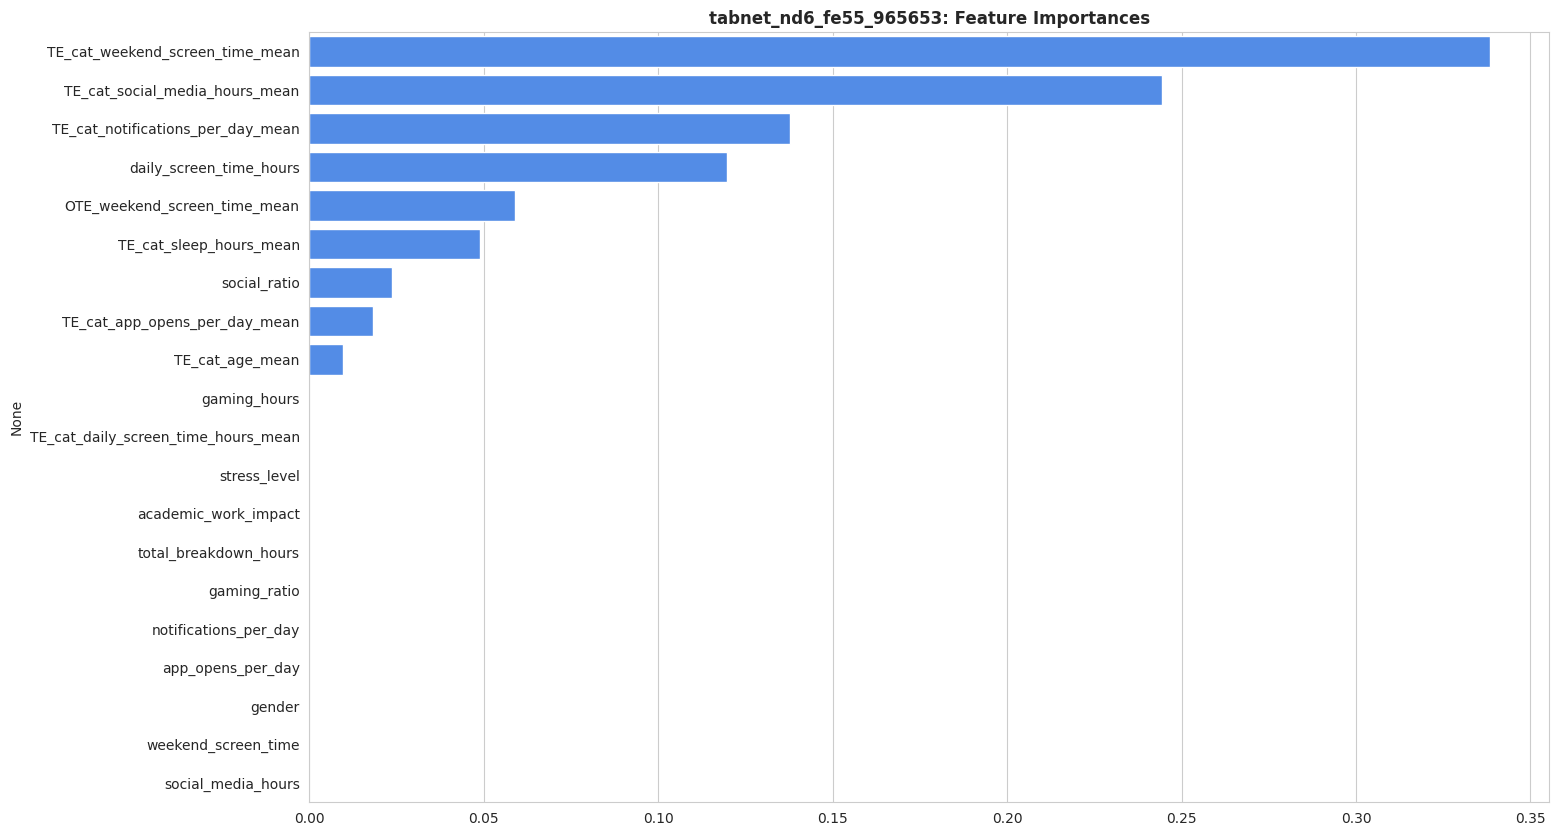

In [41]:
all_models = []

for i, _ in enumerate(list(all_predictions.keys())):
    model = all_predictions[list(all_predictions.keys())[i]]
    all_models.append(model)

## -- TabNet: Feature Importances --
for i, m in enumerate(all_models):
    feat_imp = m['model'].feature_importances_
    features = m['columns']
    df_temp  = pd.Series(dict(zip(features, feat_imp))).sort_values(ascending=False)[:20]

    plt.figure(figsize=(16, 10))
    sns.barplot(y=df_temp.index, x=df_temp.values)
    plt.title(f"{[*model_results.keys()][i]}: Feature Importances", fontweight='semibold')

    # plt.tight_layout()
    plt.show()
    print()

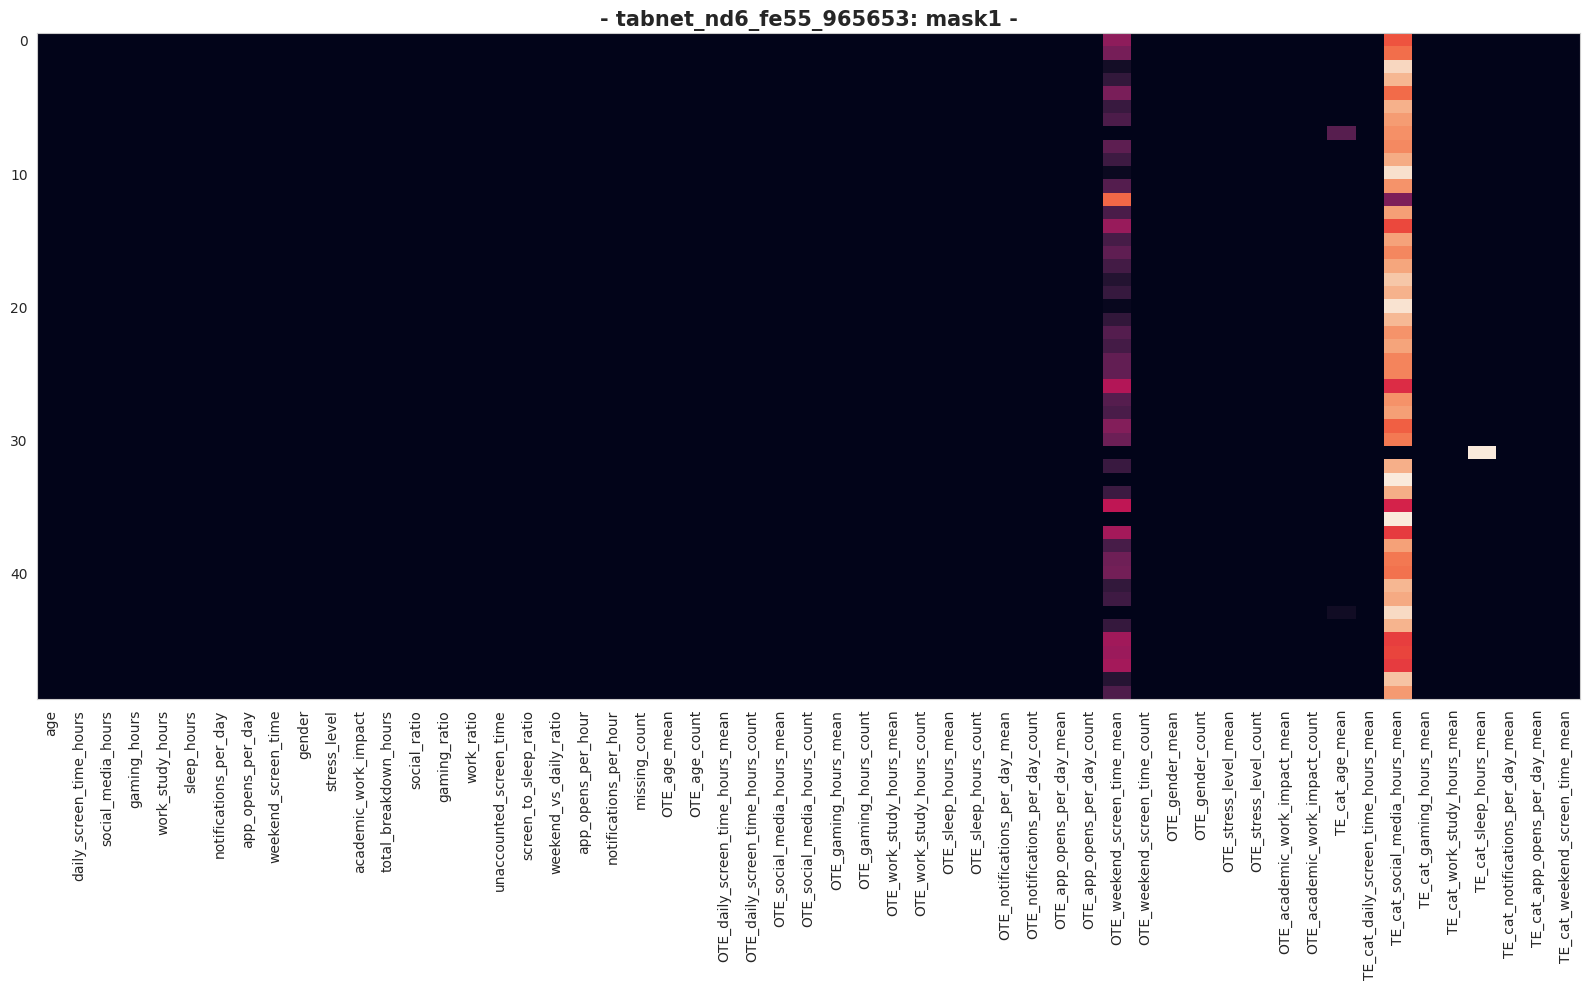

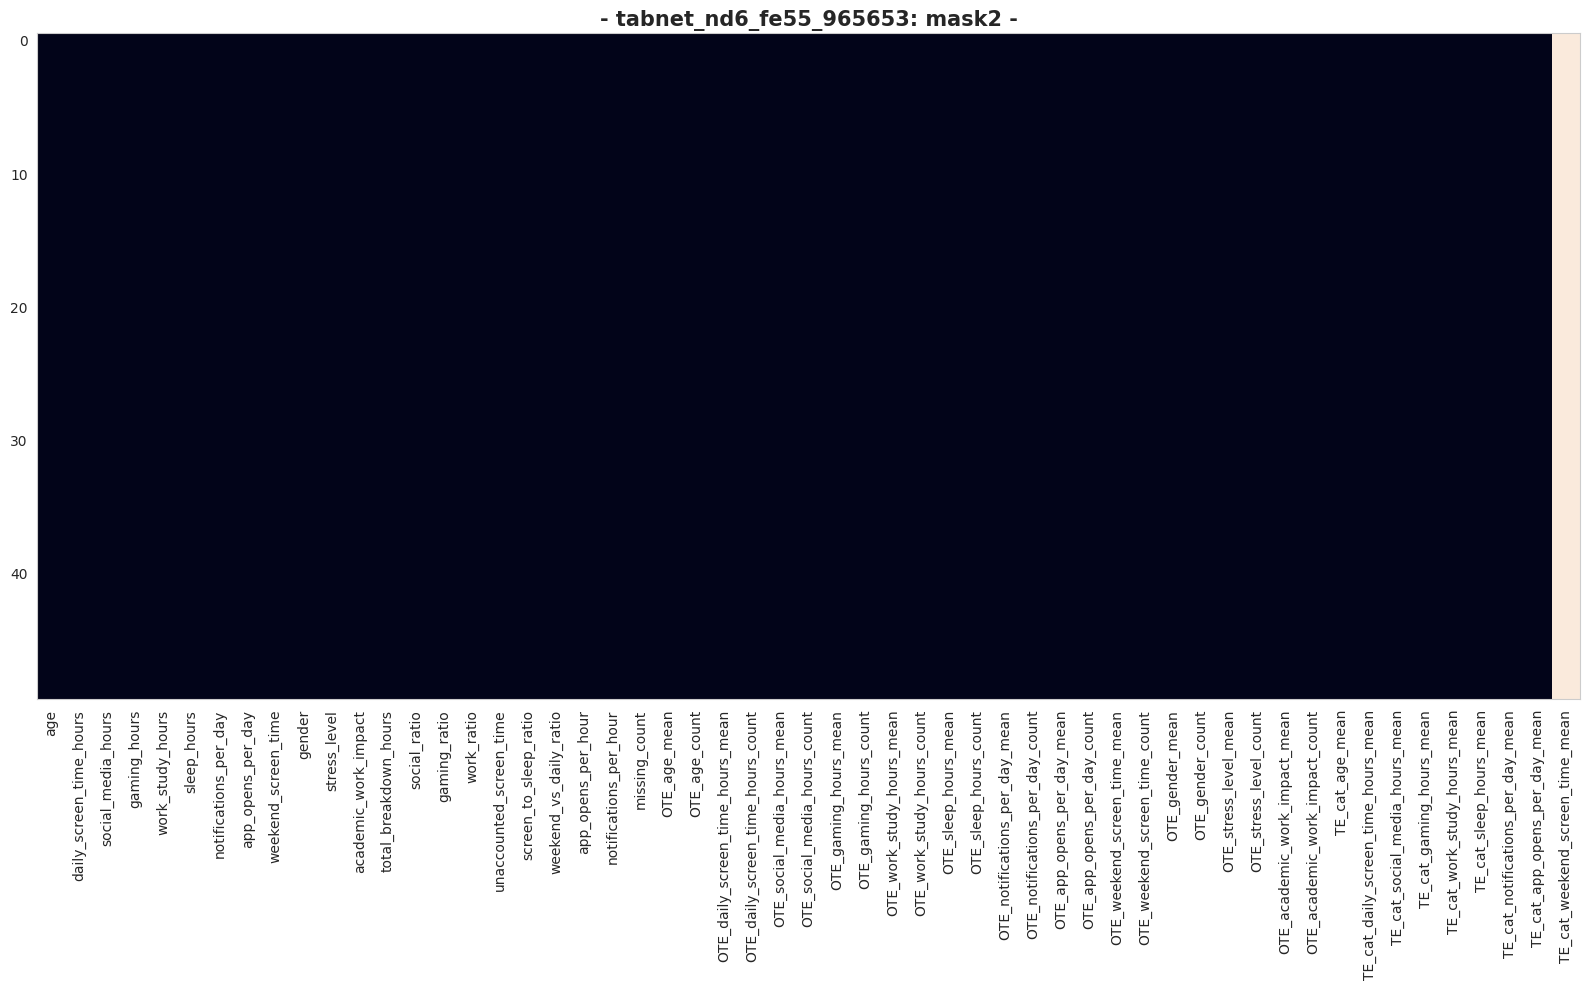

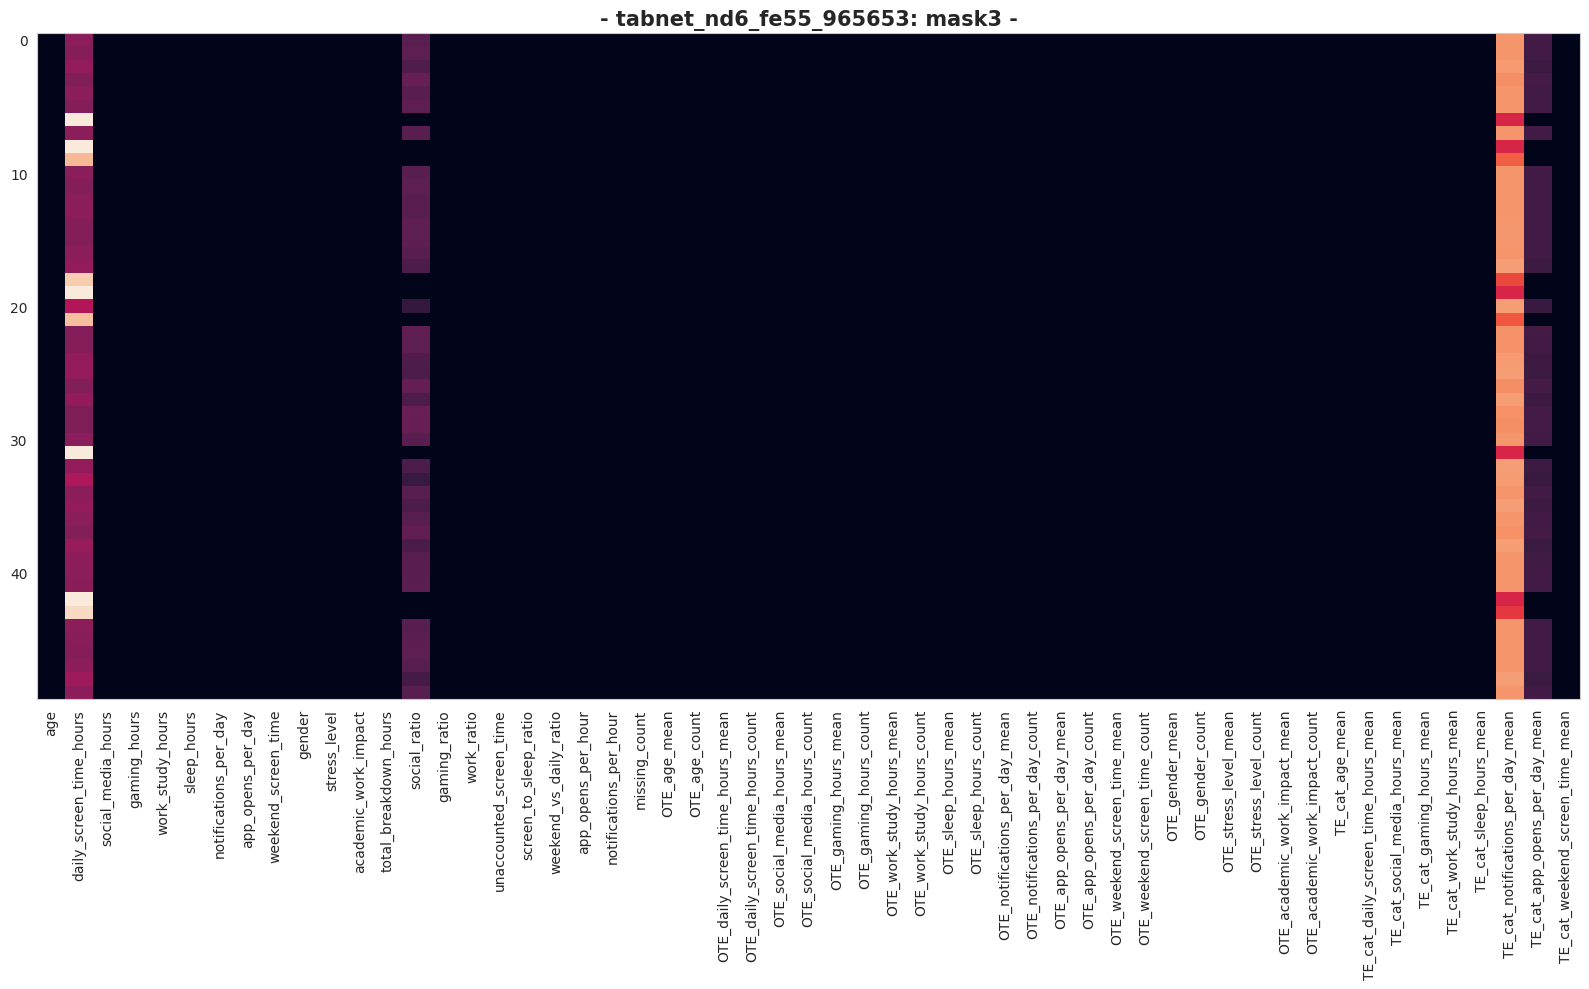

In [42]:
## -- Most used features --
explain_matrix, masks = all_models[0]['model'].explain(all_models[0]['val_data'].to_numpy())

for i in range(3):
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    ax.imshow(masks[i][:50], aspect='auto')
    ax.set_title(f"- {[*model_results.keys()][0]}: mask{i+1} -", size=15, weight='semibold')
    ax.set_xticks(range(len(all_models[0]['val_data'].columns)), all_models[0]['val_data'].columns)
    ax.tick_params('x', rotation=90)
    ax.grid()
    plt.tight_layout()
    plt.show()
    print()

In [43]:
# !rm -r /kaggle/working